In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import collections
import seaborn as sb

In [2]:
df = pd.read_csv("PerspectiveOutcomes.csv").fillna({"num_messages_comm": 0, "num_messages_ih": 0})
df

,ih_a_all,ih_b_all,tox_a_all,tox_b_all,ih_a_op,ih_b_op,tox_a_op,tox_b_op,ih_a_comm,ih_b_comm,...,speeder,commented,posted,passcode,gold_star,posit,ih_a_ca,ih_b_ca,tox_a_ca,tox_b_ca
0,0.361823,0.348515,0.133737,0.070089,0.360970,0.335827,0.078460,0.033009,0.362249,0.354860,...,0,1,1,True,0,lib,0.382053,0.364194,0.012817,0.006676
1,0.362019,0.410255,0.085755,0.031098,0.512410,0.554325,0.057006,0.020452,0.211628,0.266185,...,1,1,1,True,1,con,NaN,NaN,NaN,NaN
2,0.383066,0.322223,0.009911,0.006789,0.267132,0.233647,0.013194,0.008441,0.499001,0.410800,...,1,1,1,True,1,con,NaN,NaN,NaN,NaN
3,0.282872,0.349636,0.096769,0.038011,0.379054,0.458685,0.100023,0.039186,0.186691,0.240587,...,1,1,1,True,1,lib,0.186691,0.240587,0.093515,0.036837
4,0.425425,0.437438,0.051341,0.021750,0.256750,0.272360,0.091122,0.035728,0.594101,0.602517,...,1,1,1,True,1,con,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,0.235552,0.223638,0.035396,0.015886,0.220500,0.228770,0.051316,0.018822,0.238562,0.222612,...,1,1,1,True,1,lib,0.244652,0.229313,0.035145,0.015861
1039,0.383666,0.378626,0.028399,0.013212,NaN,NaN,NaN,NaN,0.383666,0.378626,...,1,0,1,True,0,lib,0.343404,0.298406,0.010430,0.006796
1040,0.177561,0.166600,0.024242,0.011742,0.106842,0.112467,0.030388,0.013307,0.248280,0.220734,...,1,1,1,True,1,NaN,NaN,NaN,NaN,NaN
1041,0.395352,0.387153,0.038950,0.016728,0.299257,0.251120,0.096552,0.039512,0.414571,0.414359,...,1,1,1,True,1,lib,0.192040,0.181048,0.027324,0.015055


In [3]:
df['ih_dwell_p'] = df.ih_dwell / (df.all_dwell+1)
df['ih_comments_p'] = df.num_messages_ih / df.num_messages_comm
df['total_engagement'] = df.total_likes + df.total_dislikes + df.num_messages_comm
df['ih_engagement'] = df.

In [4]:
df.dropna(subset="ih_comments_p")

,ih_a_all,ih_b_all,tox_a_all,tox_b_all,ih_a_op,ih_b_op,tox_a_op,tox_b_op,ih_a_comm,ih_b_comm,...,commented,posted,passcode,gold_star,posit,ih_a_ca,ih_b_ca,tox_a_ca,tox_b_ca,ih_comments_p
0,0.361823,0.348515,0.133737,0.070089,0.360970,0.335827,0.078460,0.033009,0.362249,0.354860,...,1,1,True,0,lib,0.382053,0.364194,0.012817,0.006676,0.000000
1,0.362019,0.410255,0.085755,0.031098,0.512410,0.554325,0.057006,0.020452,0.211628,0.266185,...,1,1,True,1,con,NaN,NaN,NaN,NaN,0.000000
2,0.383066,0.322223,0.009911,0.006789,0.267132,0.233647,0.013194,0.008441,0.499001,0.410800,...,1,1,True,1,con,NaN,NaN,NaN,NaN,0.000000
3,0.282872,0.349636,0.096769,0.038011,0.379054,0.458685,0.100023,0.039186,0.186691,0.240587,...,1,1,True,1,lib,0.186691,0.240587,0.093515,0.036837,1.000000
4,0.425425,0.437438,0.051341,0.021750,0.256750,0.272360,0.091122,0.035728,0.594101,0.602517,...,1,1,True,1,con,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,0.235552,0.223638,0.035396,0.015886,0.220500,0.228770,0.051316,0.018822,0.238562,0.222612,...,1,1,True,1,lib,0.244652,0.229313,0.035145,0.015861,0.000000
1039,0.383666,0.378626,0.028399,0.013212,NaN,NaN,NaN,NaN,0.383666,0.378626,...,0,1,True,0,lib,0.343404,0.298406,0.010430,0.006796,0.000000
1040,0.177561,0.166600,0.024242,0.011742,0.106842,0.112467,0.030388,0.013307,0.248280,0.220734,...,1,1,True,1,NaN,NaN,NaN,NaN,NaN,0.000000
1041,0.395352,0.387153,0.038950,0.016728,0.299257,0.251120,0.096552,0.039512,0.414571,0.414359,...,1,1,True,1,lib,0.192040,0.181048,0.027324,0.015055,0.000000


In [5]:
# Define affective polarization
def ap(row):
    # Pre-treatment AP
    if row['pid7'] in ["Lean Democrat", "Weak Democrat", "Strong Democrat"]:
        if row['Party1'] == "Democrat":
            pre_ap = row['pre_therm_1'] - row['pre_therm_2']
        else:
            pre_ap = row['pre_therm_2'] - row['pre_therm_1']
    elif row['pid7'] in ["Lean Republican", "Weak Republican", "Strong Republican"]:
        if row['Party1'] == "Republican":
            pre_ap = row['pre_therm_1'] - row['pre_therm_2']
        else:
            pre_ap = row['pre_therm_2'] - row['pre_therm_1']
    else:
        return None
    # Post-treatment AP
    if row['pid7'] in ["Lean Democrat", "Weak Democrat", "Strong Democrat"]:
        if row['Party1_post'] == "Democrat":
            post_ap = row['post_therm_1'] - row['post_therm_2']
        else:
            post_ap = row['post_therm_2'] - row['post_therm_1']
    elif row['pid7'] in ["Lean Republican", "Weak Republican", "Strong Republican"]:
        if row['Party1_post'] == "Republican":
            post_ap = row['post_therm_1'] - row['post_therm_2']
        else:
            post_ap = row['post_therm_2'] - row['post_therm_1']
    
    return  post_ap - pre_ap
    
df['ap'] = df.apply(ap, axis=1)
    
# Define Issue extremity

def ie(row):
    att = {"Strongly disagree": 3,
           "Disagree": 2,
           "Somewhat disagree": 1,
           "Neither agree nor disagree": 0,
           "Somewhat agree": 1,
           "Agree": 2,
           "Strongly agree": 3}

    pre_ext = att[row['pre_policy_gc']] + att[row['pre_policy_imm']]
    post_ext = att[row['post_policy_1']] + att[row['post_policy_2']]

    return post_ext - pre_ext

df['ie'] = df.apply(ie, axis=1)

# Define IH Engagement

#df['ih_engage'] = (df.ih_dwell_p + df.p_likes_ih + df.p_dislikes_ih)/3
df['ih_engage'] = (df.p_likes_ih + df.p_dislikes_ih + df.ih_comments_p)/3

In [6]:
df[df.num_messages_comm > 0]

,ih_a_all,ih_b_all,tox_a_all,tox_b_all,ih_a_op,ih_b_op,tox_a_op,tox_b_op,ih_a_comm,ih_b_comm,...,gold_star,posit,ih_a_ca,ih_b_ca,tox_a_ca,tox_b_ca,ih_comments_p,ap,ie,ih_engage
0,0.361823,0.348515,0.133737,0.070089,0.360970,0.335827,0.078460,0.033009,0.362249,0.354860,...,0,lib,0.382053,0.364194,0.012817,0.006676,0.000000,0.0,0,0.000000
1,0.362019,0.410255,0.085755,0.031098,0.512410,0.554325,0.057006,0.020452,0.211628,0.266185,...,1,con,NaN,NaN,NaN,NaN,0.000000,10.0,0,NaN
2,0.383066,0.322223,0.009911,0.006789,0.267132,0.233647,0.013194,0.008441,0.499001,0.410800,...,1,con,NaN,NaN,NaN,NaN,0.000000,0.0,0,NaN
3,0.282872,0.349636,0.096769,0.038011,0.379054,0.458685,0.100023,0.039186,0.186691,0.240587,...,1,lib,0.186691,0.240587,0.093515,0.036837,1.000000,-2.0,0,0.333333
4,0.425425,0.437438,0.051341,0.021750,0.256750,0.272360,0.091122,0.035728,0.594101,0.602517,...,1,con,NaN,NaN,NaN,NaN,0.000000,0.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,0.235552,0.223638,0.035396,0.015886,0.220500,0.228770,0.051316,0.018822,0.238562,0.222612,...,1,lib,0.244652,0.229313,0.035145,0.015861,0.000000,20.0,0,0.000000
1039,0.383666,0.378626,0.028399,0.013212,NaN,NaN,NaN,NaN,0.383666,0.378626,...,0,lib,0.343404,0.298406,0.010430,0.006796,0.000000,0.0,0,0.171717
1040,0.177561,0.166600,0.024242,0.011742,0.106842,0.112467,0.030388,0.013307,0.248280,0.220734,...,1,NaN,NaN,NaN,NaN,NaN,0.000000,-20.0,0,NaN
1041,0.395352,0.387153,0.038950,0.016728,0.299257,0.251120,0.096552,0.039512,0.414571,0.414359,...,1,lib,0.192040,0.181048,0.027324,0.015055,0.000000,0.0,0,NaN


In [7]:
df[['num_messages_comm', 'num_messages_ih', 'p_likes_ih', 'p_dislikes_ih', 'ih_engage']]

,num_messages_comm,num_messages_ih,p_likes_ih,p_dislikes_ih,ih_engage
0,2.0,0.0,0.000000,0.000000,0.000000
1,1.0,0.0,0.000000,NaN,NaN
2,1.0,0.0,0.000000,NaN,NaN
3,1.0,1.0,0.000000,0.000000,0.333333
4,1.0,0.0,0.000000,NaN,NaN
...,...,...,...,...,...
1038,5.0,0.0,0.000000,0.000000,0.000000
1039,4.0,0.0,0.181818,0.333333,0.171717
1040,1.0,0.0,0.000000,NaN,NaN
1041,5.0,0.0,0.000000,NaN,NaN


In [8]:
df['ih_engage_zero'] = df.ih_engage.fillna(0)
df['ih_a_all_zero'] = df.ih_a_all.fillna(0)

for y in ["panas", "panas_pos", "panas_neg", 
         "ap", "ie",
         "delta_ih", "ih_engage", "ih_a_all"]:

    df[y] = (df[y] - df[y].mean())/df[y].std()

df['ih_engage_mean'] = df.ih_engage.fillna(0)
df['ih_a_all_mean'] = df.ih_a_all.fillna(0)

In [9]:
for y in ["panas", "panas_pos", "panas_neg", 
         "ap", "ie",
         "delta_ih", "ih_engage", "ih_a_all",
         "ih_engage_zero", "ih_engage_mean",
         "ih_a_all_zero", "ih_a_all_mean"]:

    print(y, len(df.dropna(subset=[y])))

panas 1043
panas_pos 1043
panas_neg 1043
ap 888
ie 1043
delta_ih 1042
ih_engage 424
ih_a_all 981
ih_engage_zero 1043
ih_engage_mean 1043
ih_a_all_zero 1043
ih_a_all_mean 1043


In [10]:
np.random.seed(8675309)
n_boots=25000

for y in ["panas", "panas_pos", "panas_neg", 
         "ap", "ie",
         "delta_ih", "ih_engage", "ih_a_all",
         "ih_engage_zero", "ih_engage_mean",
         "ih_a_all_zero", "ih_a_all_mean"]:
    
    b = round(df[df.condition == "treat"][y].mean() - df[df.condition == "control"][y].mean(), 4)
    
    boots = []
    for s in range(n_boots):
        boot = df.sample(frac=1, replace=True)
        boots.append(boot[boot.condition == "treat"][y].mean() - boot[boot.condition == "control"][y].mean())
    ci_95 = [round(i, 4) for i in np.quantile(boots, (0.025, 0.975))]
    ci_90 = [round(i, 4) for i in np.quantile(boots, (0.05, 0.95))]

    print(y, b, ci_95, ci_90, stats.ttest_ind(df[df.condition == "treat"][y],
                                             df[df.condition == "control"][y],
                                             nan_policy = "omit"))

KeyboardInterrupt: 

# HTE by Start Date

In [18]:
df['day'] = [i.split(' ')[0] for i in df.StartDate]

In [71]:
df.day.value_counts()

12/14/2023    666
12/13/2023    303
12/12/2023     74
Name: day, dtype: int64

In [30]:
b_ih = []
ci_ih = []
b_emo = []
ci_emo = []
ds = []

n_boots = 5000

for d in sorted(list(set([i.split(' ')[0] for i in df.StartDate]))):
    _df = df[df.day == d]
    ds.append(d)
    b_ih.append(round(_df[_df.condition == "treat"]['ih_a_all'].mean() - _df[_df.condition == "control"]['ih_a_all'].mean(), 4))
    b_emo.append(round(_df[_df.condition == "treat"]['panas'].mean() - _df[_df.condition == "control"]['panas'].mean(), 4))

    boots_ih = []
    boots_emo = []

    for i in range(n_boots):
        boot_df = _df.sample(frac=1, replace=True)
        boots_ih.append(round(boot_df[boot_df.condition == "treat"]['ih_a_all'].mean() - boot_df[boot_df.condition == "control"]['ih_a_all'].mean(), 4))
        boots_emo.append(round(boot_df[boot_df.condition == "treat"]['panas'].mean() - boot_df[boot_df.condition == "control"]['panas'].mean(), 4))

    ci_ih.append(np.quantile(boots_ih, (0.025, 0.975)))
    ci_emo.append(np.quantile(boots_emo, (0.025, 0.975)))

[i for i in zip(ds, b_ih, ci_ih, b_emo, ci_emo)]

[('12/12/2023',
  0.1218,
  array([-0.327005,  0.56431 ]),
  -0.176,
  array([-0.5962225,  0.26281  ])),
 ('12/13/2023',
  0.1251,
  array([-0.1128025,  0.3557075]),
  0.2216,
  array([-0.001605,  0.442105])),
 ('12/14/2023',
  0.1315,
  array([-0.0201025,  0.2857175]),
  0.1316,
  array([-0.019805,  0.2811  ]))]

In [29]:
import numpy as np

b_ih = []
ci_ih = []
b_emo = []
ci_emo = []
ds = []

n_boots = 5000

# Ensure 'StartDate' column is converted to string if it is not
df['StartDate'] = df['StartDate'].astype(str)

# Loop through each unique day
for d in sorted(list(set([i.split(' ')[0] for i in df['StartDate']]))):
    _df = df[df['day'] == d]
    ds.append(d)
    
    treat_ih_mean = _df[_df['condition'] == "treat"]['ih_a_all'].mean()
    control_ih_mean = _df[_df['condition'] == "control"]['ih_a_all'].mean()
    treat_emo_mean = _df[_df['condition'] == "treat"]['panas'].mean()
    control_emo_mean = _df[_df['condition'] == "control"]['panas'].mean()
    
    b_ih.append(round(treat_ih_mean - control_ih_mean, 4))
    b_emo.append(round(treat_emo_mean - control_emo_mean, 4))

    boots_ih = []
    boots_emo = []

    for i in range(n_boots):
        boot_df = _df.sample(frac=1, replace=True)
        boots_ih_mean = boot_df[boot_df['condition'] == "treat"]['ih_a_all'].mean() - boot_df[boot_df['condition'] == "control"]['ih_a_all'].mean()
        boots_emo_mean = boot_df[boot_df['condition'] == "treat"]['panas'].mean() - boot_df[boot_df['condition'] == "control"]['panas'].mean()
        
        boots_ih.append(round(boots_ih_mean, 4))
        boots_emo.append(round(boots_emo_mean, 4))

    ci_ih.append(np.percentile(boots_ih, (2.5, 97.5)))
    ci_emo.append(np.percentile(boots_emo, (2.5, 97.5)))

results = [i for i in zip(ds, b_ih, ci_ih, b_emo, ci_emo)]
results

[('12/12/2023',
  0.1218,
  array([-0.3084075,  0.581715 ]),
  -0.176,
  array([-0.59381 ,  0.250315])),
 ('12/13/2023',
  0.1251,
  array([-0.1055025,  0.3533025]),
  0.2216,
  array([0.0011875, 0.4416075])),
 ('12/14/2023',
  0.1315,
  array([-0.027205 ,  0.2857025]),
  0.1316,
  array([-0.0230175,  0.280215 ]))]

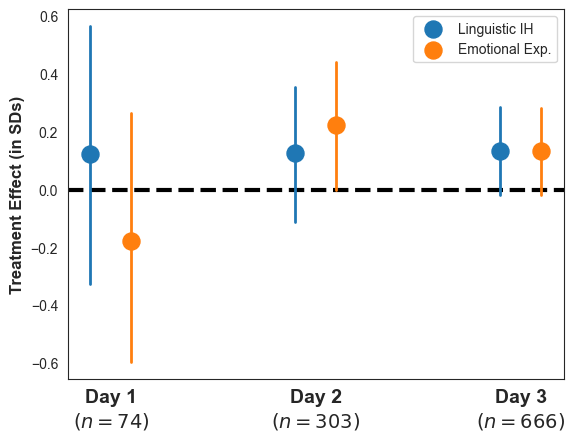

In [77]:
sb.set_style("white")

plt.axhline(0, lw=3, ls="--", c="black")

for x, ci in zip([0.9, 1.9, 2.9],ci_ih):
    plt.plot([x,x],ci,color="tab:blue",lw=2)
plt.scatter([0.9, 1.9, 2.9],b_ih,c="tab:blue", label="Linguistic IH",s=150)

for x, ci in zip([1.1, 2.1, 3.1],ci_emo):
    plt.plot([x,x],ci,color="tab:orange",lw=2)
plt.scatter([1.1, 2.1, 3.1],b_emo,c="tab:orange", label="Emotional Exp.",s=150)


plt.xticks([1,2,3],["Day 1\n$(n=74)$", "Day 2\n$(n=303)$", "Day 3\n$(n=666)$"], 
           fontweight="bold", fontsize=14)
plt.ylabel("Treatment Effect (in SDs)", fontsize=12, fontweight="bold")
plt.legend()
plt.savefig("Dayblation.png", dpi=300)
plt.show()

In [11]:
np.random.seed(8675309)

for y in ["panas", "panas_pos", "panas_neg", 
         "ap", "ie",
         "delta_ih", "ih_engage", "ih_a_all"]:

    df[y] = (df[y] - df[y].mean())/df[y].std()

    a = round(df[df.condition == "treat"][y].mean(), 4)
    b = round(df[df.condition == "control"][y].mean(), 4)
    
    a_boots = []
    b_boots = []
    
    for s in range(10000):
        boot = df.sample(frac=1, replace=True)
        a_boots.append(boot[boot.condition == "treat"][y].mean())
        b_boots.append(boot[boot.condition == "control"][y].mean())
        
    ci_a_95 = [round(i, 4) for i in np.quantile(a_boots, (0.025, 0.975))]
    ci_a_90 = [round(i, 4) for i in np.quantile(a_boots, (0.05, 0.95))]
    
    ci_b_95 = [round(i, 4) for i in np.quantile(b_boots, (0.025, 0.975))]
    ci_b_90 = [round(i, 4) for i in np.quantile(b_boots, (0.05, 0.95))]

    print(y, " Treat ", a, ci_a_90, ci_a_95)
    print(y, " Control ", b, ci_b_90, ci_b_95)

panas  Treat  0.0655 [-0.0076, 0.1361] [-0.0199, 0.15]
panas  Control  -0.0719 [-0.1437, -0.0002] [-0.1574, 0.0138]



KeyboardInterrupt

